# Reconstructing a real 802.11g capture

This notebook rebuilds a measured OFDM burst from a transmitted waveform plus a
set of fitted hardware impairments, and checks the rebuild against the real
receiver output.

It is the **reverse direction** from the rest of this repository. `synth_dataset.py`
*samples* impairment parameters from modelled distributions to make new SRRC
captures; here the parameters were *measured* from one real capture and are
replayed to see how much of that capture the model explains.

Everything comes from one packaged file, `wifi_recon_30BF795_89_2400.npz`:
radio 30BF795, 802.11g CBW20 MCS2 at 2450 MHz, gain 89, captured at 40 MS/s on a
BB60C. The raw captures are not shipped, so the file carries the burst average
rather than the 80 individual bursts.

**What you should see:** the deterministic part of the chain reproduces the
stored model *bit for bit*, and its residual against the real capture lands on
the published number.

In [1]:
from pathlib import Path
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

BASE = Path.cwd()
if not (BASE / "data" / "wifi_recon_30BF795_89_2400.npz").exists():
    BASE = BASE.parent                       # in case the cwd is a subfolder
d = np.load(BASE / "data" / "wifi_recon_30BF795_89_2400.npz")

FS = float(d["fs"])
N = len(d["ts_tx"])
GUARD = int(d["guard"])
sl = slice(GUARD, -GUARD)                    # the fit/score window
rms = lambda v: float(np.sqrt(np.mean(np.abs(v[sl]) ** 2)))

print(f"{N:,} samples per burst at {FS/1e6:.0f} MS/s, "
      f"{int(d['nkept'])} bursts averaged, guard {GUARD}")
print(f"per-burst SNR {float(d['snr']):.2f} dB  ->  averaged noise floor "
      f"{float(d['floor']):.6f}")

52,000 samples per burst at 40 MS/s, 80 bursts averaged, guard 256
per-burst SNR 27.60 dB  ->  averaged noise floor 0.004662


## 1. What is in the file

Four groups: the waveforms, the blocks that were *fitted*, the quantities that
were *measured* per run, and the linear operators needed to replay the chain.

In [2]:
groups = {
    "waveforms":        ["ts_tx", "ts_real", "ts_recon", "ts_det"],
    "fitted blocks":    ["taps", "a3", "pn_mask", "pn_slope", "pn_l10k",
                         "pn_rms_deg", "iq_db", "iq_deg", "settling"],
    "measured per run": ["cfo", "taus", "ppm", "cphase", "snr", "floor",
                         "nkept"],
    "replay operators": ["op_rxh", "op_rip", "op_ks", "op_nsd", "op_gain"],
    "scores":           ["r_lin", "r_cub", "r_full"],
}
for name, keys in groups.items():
    print(f"\n{name}")
    for k in keys:
        v = d[k]
        shape = "scalar" if v.shape == () else str(v.shape)
        extra = "" if v.shape != () else f" = {v.item():.6g}" if v.dtype.kind in "fi" else f" = {v.item()}"
        print(f"   {k:<12} {shape:<12}{extra}")


waveforms
   ts_tx        (52000,)    
   ts_real      (52000,)    
   ts_recon     (52000,)    
   ts_det       (52000,)    

fitted blocks
   taps         (3,)        
   a3           scalar       = (-0.0019236316346647581+0.000800894193953673j)
   pn_mask      (5, 2)      
   pn_slope     scalar       = -10.7252
   pn_l10k      scalar       = -81.3976
   pn_rms_deg   scalar       = 1.99332
   iq_db        scalar       = 0.0141596
   iq_deg       scalar       = -0.10811
   settling     (52000,)    

measured per run
   cfo          (80,)       
   taus         (80,)       
   ppm          scalar       = -2.39678
   cphase       scalar       = 0.0253783
   snr          scalar       = 27.5968
   floor        scalar       = 0.00466246
   nkept        scalar       = 80

replay operators
   op_rxh       (601,)      
   op_rip       (52000,)    
   op_ks        (3,)        
   op_nsd       scalar       = 0.0227783
   op_gain      scalar       = (1.0015055479960167+0.0003312750362136227j)


## 2. The receive operator

Two linear stages sit between the transmitter and the samples we compare
against, and both are **calibrations rather than fitted parameters** — they
describe the instrument, not the radio:

* `op_rxh` — the BB60C anti-alias response (601-tap FIR).
* `op_rip` — an in-band ripple correction. It is common across radios
  (correlation 0.94 here, 0.99 across eight radios on the SRRC side) and across
  a 12 dB drive change, so it belongs to the measurement setup.

The ripple is stored as the built frequency-domain operator rather than the
curve it came from, because remove-and-re-apply has to be the *same* operator —
re-realising it as a windowed FIR under-reproduced the curve and made the chain
worse than skipping it entirely. (The operator shipped here is the *residual*
ripple, after the component common to the radio population is accounted for, so
its in-band rms is smaller than the raw measured curve.)

ripple in-band rms 0.091 dB


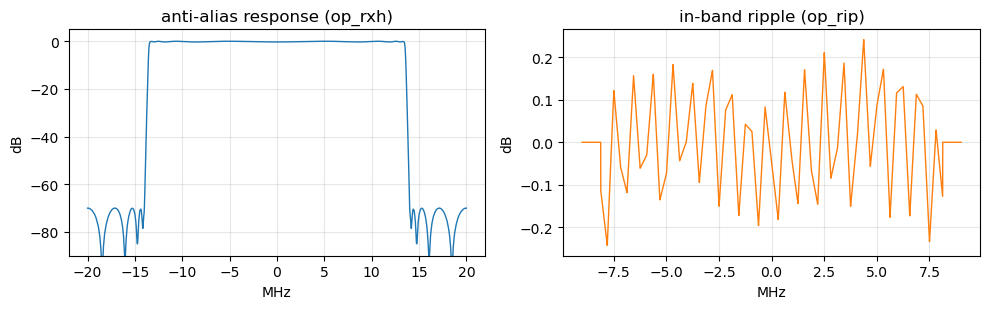

In [3]:
RXH, RIP = d["op_rxh"], d["op_rip"]
_h = len(RXH) // 2

def K(z):
    # the known receive operators: anti-alias filter, then in-band ripple
    z = scipy.signal.oaconvolve(z, RXH)[_h:_h + N]
    return np.fft.ifft(np.fft.fft(z) * RIP)

f = np.fft.fftshift(np.fft.fftfreq(4096, 1 / FS)) / 1e6
H = np.fft.fftshift(np.abs(np.fft.fft(RXH, 4096)))
fr = np.fft.fftshift(np.fft.fftfreq(N, 1 / FS)) / 1e6
Rp = 20 * np.log10(np.fft.fftshift(np.abs(RIP)))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(f, 20 * np.log10(H / H.max()), lw=1.0)
ax[0].set(xlabel="MHz", ylabel="dB", title="anti-alias response (op_rxh)",
          ylim=(-90, 5))
ax[0].grid(alpha=0.3)
inb = np.abs(fr) <= 9
ax[1].plot(fr[inb], Rp[inb], lw=1.0, color="C1")
ax[1].set(xlabel="MHz", ylabel="dB", title="in-band ripple (op_rip)")
ax[1].grid(alpha=0.3)
plt.tight_layout()
print(f"ripple in-band rms {Rp[inb].std():.3f} dB")

## 3. The deterministic chain

The transmitter model is a **Hammerstein cascade**: one memoryless cubic
followed by three symbol-spaced linear taps.

$$y[n] \;=\; \sum_j c_j\Big( u[n-k_j] \;+\; a_3\, u[n-k_j]\,\big|u[n-k_j]\big|^2 \Big),
\qquad u = K(x)$$

The ordering matters and is not a free choice. The cubic has to act **before**
the receive operator, since the receiver cannot un-compress what the PA did —
so `K` is applied to the *regressors*, not to the measurement. This is the
"forward fit": nothing is applied twice and the measured `ts_real` is never
altered.

In [4]:
x = d["ts_tx"].astype(np.complex128)
y = d["ts_real"].astype(np.complex128)
taps, a3, ks = d["taps"], complex(d["a3"]), d["op_ks"]

bx, bx3 = K(x), K(x * np.abs(x) ** 2)        # pre-filtered basis
model = sum(taps[j] * (np.roll(bx, int(ks[j])) + a3 * np.roll(bx3, int(ks[j])))
            for j in range(len(ks)))

print(f"tap lags {[int(k) for k in ks]}   a3 = {a3:+.6f}")
for j, k in enumerate(ks):
    print(f"   c[{int(k):+d}] = {taps[j]:+.6f}   |c| {abs(taps[j]):.5f}")

# The linear-only baseline REFITS the taps with the cubic disabled. Simply
# dropping the cubic from the a3-optimal taps is a different (worse) model and
# reads 0.049894 -- the taps absorb some of the compression when it is present.
A = np.stack([np.roll(bx, int(k)) for k in ks], 1)
c_lin = np.linalg.lstsq(A[sl], y[sl], rcond=None)[0]
linear = A @ c_lin

print(f"\nlinear only   residual {rms(y - linear):.6f}   "
      f"(published r_lin {float(d['r_lin']):.6f})")
print(f"+ PA cubic    residual {rms(y - model):.6f}   "
      f"(published r_cub {float(d['r_cub']):.6f})")

# the stored deterministic output should be reproduced exactly
err = rms(model - d["ts_det"])
print(f"\nrebuild vs stored ts_det: {err:.3e}")
assert err == 0.0, "deterministic replay is not bit-exact"
print("bit-exact.")

tap lags [-3, 0, 3]   a3 = -0.001924+0.000801j
   c[-3] = +0.019167-0.017215j   |c| 0.02576
   c[+0] = +0.988390-0.008469j   |c| 0.98843
   c[+3] = +0.001099-0.014105j   |c| 0.01415

linear only   residual 0.049646   (published r_lin 0.049646)
+ PA cubic    residual 0.049531   (published r_cub 0.049531)

rebuild vs stored ts_det: 0.000e+00
bit-exact.


Note how little the cubic buys: 0.049646 → 0.049531, about 0.2%. At this drive
level `a3` is small enough that the compression term is ~0.6% of the linear term
in rms. The PA is real but it is not what limits this reconstruction.

## 4. The burst transient

A burst-repetitive phase transient, measured as a profile in position through the
burst. It is **phase only** — the radial part was measured and deliberately not
injected.

This is the single largest deterministic term at 2.4 GHz, precisely because
there is so little compression there to disentangle it from.

+ burst transient  residual 0.032801   (was 0.049531)
peak-to-peak 8.94 deg, rms 2.28 deg


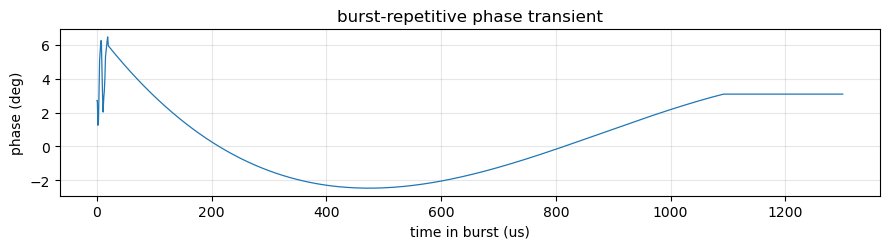

In [5]:
settling = d["settling"]
v = model * np.exp(1j * settling)
print(f"+ burst transient  residual {rms(y - v):.6f}"
      f"   (was {rms(y - model):.6f})")

t = np.arange(N) / FS * 1e6
plt.figure(figsize=(9, 2.6))
plt.plot(t, np.degrees(settling), lw=0.9)
plt.xlabel("time in burst (us)"); plt.ylabel("phase (deg)")
plt.title("burst-repetitive phase transient"); plt.grid(alpha=0.3)
plt.tight_layout()
print(f"peak-to-peak {np.ptp(np.degrees(settling)):.2f} deg, "
      f"rms {np.degrees(settling).std():.2f} deg")

## 5. The blocks that are drawn per burst

Everything so far is deterministic: the same for all 80 bursts. The remaining
blocks are **stochastic or per-burst**, so they cannot be replayed from a burst
average — each burst gets its own realisation, and the full pipeline runs the
chain 80 times and averages, exactly as it does to the real data.

Their fitted levels are in the file, so we can at least see how large each one
is before deciding it matters.

In [6]:
pn = d["pn_mask"]
print("phase noise      power-law mask, fitted as SSB L(f), injected as "
      "S_phi = L + 3.01 dB")
for fo, lv in pn:
    print(f"                    {fo:>9,.0f} Hz   {lv:+7.2f} dBc/Hz")
print(f"                    slope {float(d['pn_slope']):+.2f} dB/decade, "
      f"{float(d['pn_rms_deg']):.3f} deg rms per burst")
print(f"\nIQ imbalance     {float(d['iq_db']):+.4f} dB, "
      f"{float(d['iq_deg']):+.4f} deg  ->  image {float(d['irr']):.1f} dBc")
cfo = d["cfo"]
print(f"CFO              {cfo.mean():+.1f} Hz, per-burst sd {cfo.std(ddof=1):.2f} Hz"
      f"  ({cfo.mean()/2450e6*1e6:+.4f} ppm)")
print(f"sampling clock   {float(d['ppm']):+.4f} ppm, "
      f"sub-sample phase {float(d['cphase']):+.5f} samples")
print(f"AWGN             sigma {float(d['op_nsd']):.6f} per component")
print(f"bulk delay       per-burst sd {d['taus'].std(ddof=1):.3f} samples")

phase noise      power-law mask, fitted as SSB L(f), injected as S_phi = L + 3.01 dB
                        1,000 Hz    -67.66 dBc/Hz
                       10,000 Hz    -78.39 dBc/Hz
                      100,000 Hz    -89.11 dBc/Hz
                    1,000,000 Hz    -99.84 dBc/Hz
                    20,000,000 Hz   -113.79 dBc/Hz
                    slope -10.73 dB/decade, 1.993 deg rms per burst

IQ imbalance     +0.0142 dB, -0.1081 deg  ->  image -58.1 dBc
CFO              -5928.9 Hz, per-burst sd 3.45 Hz  (-2.4200 ppm)
sampling clock   -2.3968 ppm, sub-sample phase +0.02538 samples
AWGN             sigma 0.022778 per component
bulk delay       per-burst sd 0.278 samples


Two points worth pausing on.

**The burst average carries no CFO.** The aligner de-rotates every burst by its
own offset before averaging, so `ts_real` lives in a CFO-free frame. Applying the
mean CFO to the rebuild above makes the match *worse* by a factor of ~30 — it is
already removed. The CFO matters for per-burst work, not here.

**Averaging 80 bursts drops incoherent terms by** $10\log_{10}80 = 19$ **dB.**
That is why the noise floor is 0.0047 while the per-burst SNR is 27.6 dB, and it
is also why phase noise nearly vanishes from this comparison: what survives
averaging is its mean effect, a shrinkage of $\exp(-\sigma_\varphi^2/2)$, which at
2.0 deg rms is a 0.06% amplitude change.

## 6. Where the reconstruction stands

In [7]:
rows = [("linear taps only",            float(d["r_lin"])),
        ("+ PA cubic (Hammerstein)",    float(d["r_cub"])),
        ("+ burst transient",           rms(y - v)),
        ("full chain, 80 bursts",       float(d["r_full"]))]
floor = float(d["floor"])
print(f"{'model':<30}{'residual':>10}{'x floor':>10}")
for name, r in rows:
    print(f"{name:<30}{r:>10.6f}{r/floor:>10.1f}")
print(f"{'averaged noise floor':<30}{floor:>10.6f}{1.0:>10.1f}")

model                           residual   x floor
linear taps only                0.049646      10.6
+ PA cubic (Hammerstein)        0.049531      10.6
+ burst transient               0.032801       7.0
full chain, 80 bursts           0.024132       5.2
averaged noise floor            0.004662       1.0


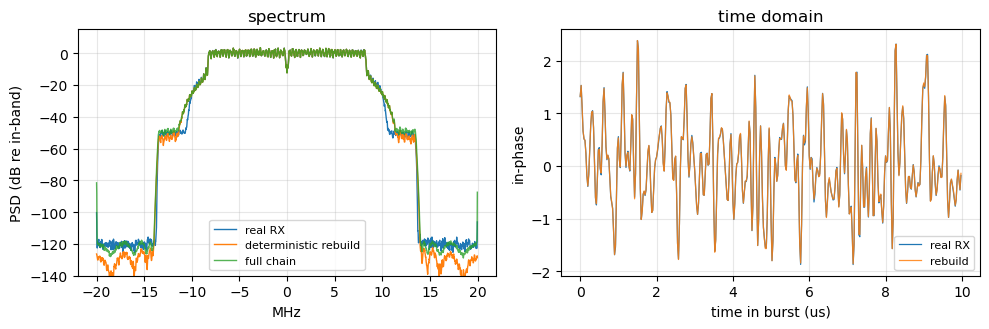

In [8]:
def psd(v):
    fq, P = scipy.signal.welch(v, fs=FS, nperseg=2048, noverlap=1024,
                               return_onesided=False)
    return np.fft.fftshift(fq) / 1e6, np.fft.fftshift(P)

fq, Py = psd(y[sl])
_, Pv = psd(v[sl])
_, Pr = psd(d["ts_recon"][sl])
occ = np.abs(fq) <= 9
nd = lambda P: 10 * np.log10(P / P[occ].mean())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(fq, nd(Py), lw=1.0, label="real RX")
ax[0].plot(fq, nd(Pv), lw=1.0, label="deterministic rebuild")
ax[0].plot(fq, nd(Pr), lw=1.0, label="full chain", alpha=0.8)
ax[0].set(xlabel="MHz", ylabel="PSD (dB re in-band)", ylim=(-140, 15),
          title="spectrum")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

i0 = N // 2
z = slice(i0, i0 + 400)
tt = np.arange(400) / FS * 1e6
ax[1].plot(tt, y[z].real, lw=0.9, label="real RX")
ax[1].plot(tt, v[z].real, lw=0.9, label="rebuild", alpha=0.85)
ax[1].set(xlabel="time in burst (us)", ylabel="in-phase", title="time domain")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout()

## 7. What this file cannot do

The deterministic chain is exactly reproducible here, but three things need the
raw captures rather than a burst average:

* **Re-deriving the fits.** Phase noise, IQ imbalance and the noise level are all
  estimated from the *scatter* of the 80 bursts about their average. Only the
  average is packaged, so the fitted values can be replayed but not re-estimated.
* **The full-chain number.** `r_full = 0.024132` comes from running the chain 80
  times with independent phase-noise, CFO and AWGN draws and averaging the
  result through the same aligner used on the real data.
* **Per-burst behaviour.** Every headline metric here is computed on the burst
  average, where incoherent terms fall 19 dB. Nothing on this page can see what
  an individual burst does.

For any of those, the full pipeline is `wifi_reconstruct.py`, which starts from
the SigMF captures: burst detection, alignment, coherent averaging, then the
fits above.

### One caution about reading the residuals

The full chain sits at **5.2x the averaged noise floor**, not at it. The model is
not noise-limited, and the shortfall is structural rather than statistical — the
memoryless cubic's regrowth skirt falls off too fast, so the reconstruction runs
about 4 dB hot in the shoulder. A PA model with memory would widen it. Treat
`r_full` as a fidelity score, not as evidence the model is complete.